11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training shape: (60000, 28, 28, 1), Test shape: (10000, 28, 28, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 120s 248ms/step - loss: 0.1613 - val_loss: 0.0994
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 116s 248ms/step - loss: 0.0952 - val_loss: 0.0904
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 212ms/step - loss: 0.0898 - val_loss: 0.0875
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 204ms/step - loss: 0.0873 - val_loss: 0.0855
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 205ms/step - loss: 0.0858 - val_loss: 0.0846
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 205ms/step - loss: 0.0847 - val_loss: 0.0836
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 201ms/step - loss: 0.0839 - val_loss: 0.0828
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 95s 202ms/step - loss: 0.0833 - val_loss: 0.0824
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - loss: 0.0828 - val_loss: 0.0821
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 203ms/step - loss: 0.0823 - val_loss: 0.0821
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - loss: 0.0820 - val_loss: 0.0813
Epoch 12/15


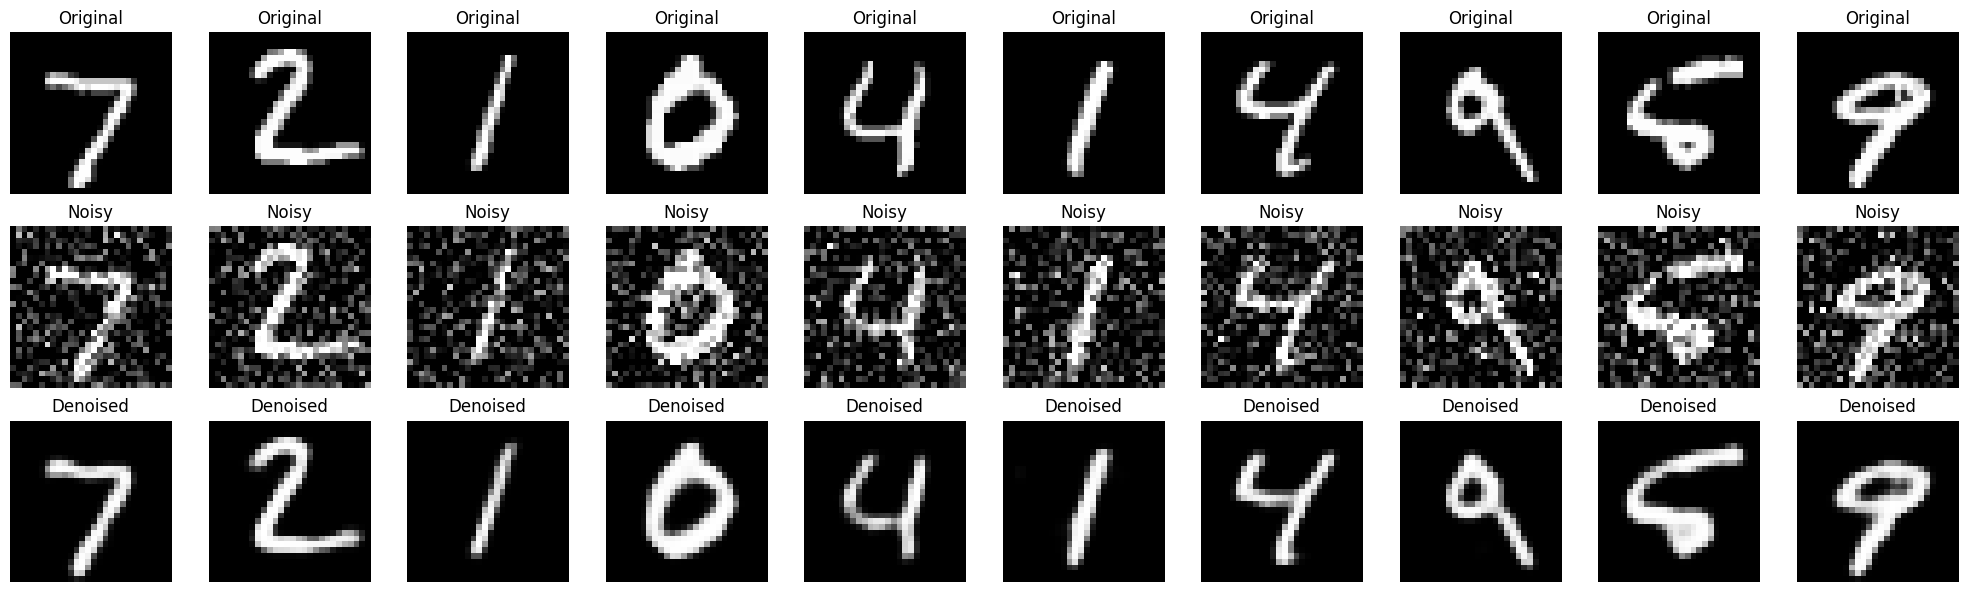

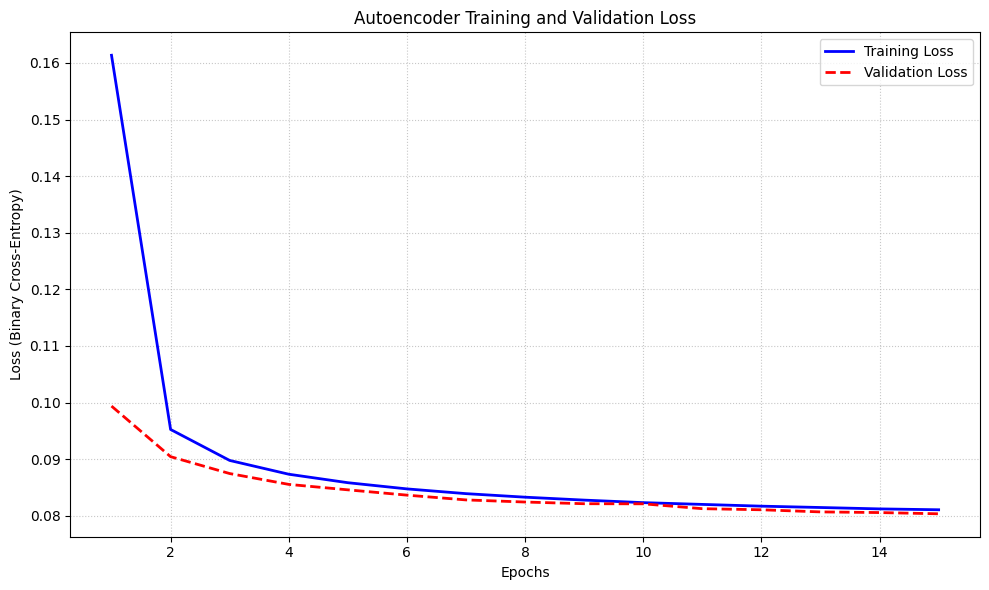

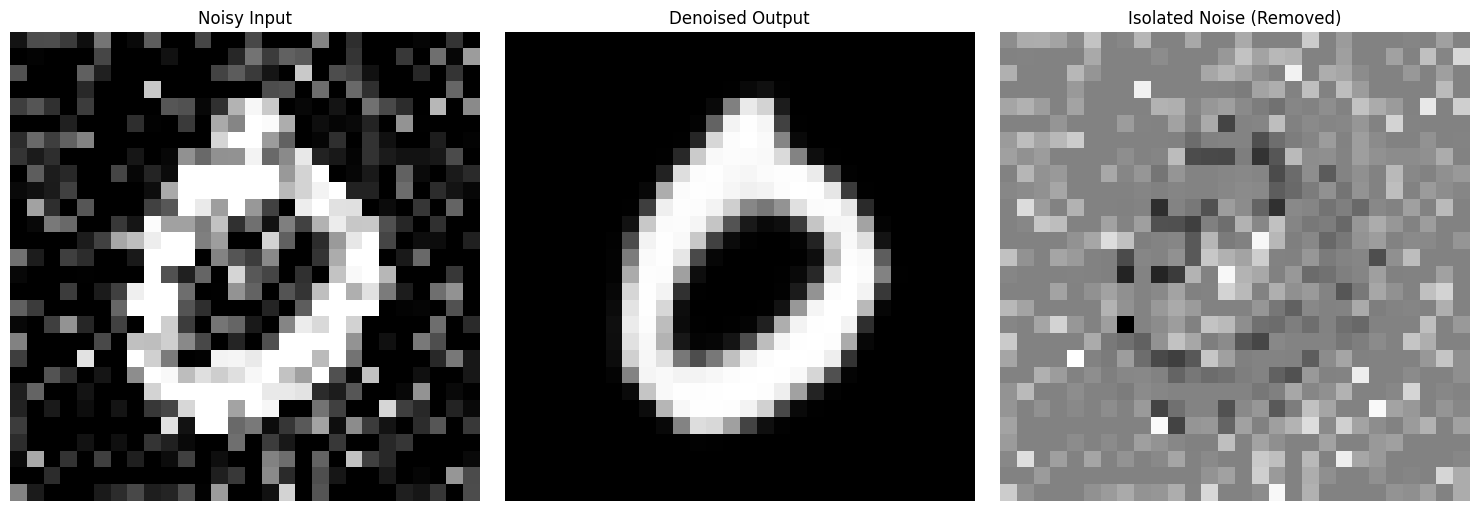

Final Training Loss:   0.0811
Final Validation Loss: 0.0803


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and Preprocess
(x_train, _), (x_test, _) = datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)
print(f"Training shape: {x_train.shape}, Test shape: {x_test.shape}")

# 2. Add Noise
noise_factor = 0.3
x_train_noisy = tf.clip_by_value(x_train + noise_factor * tf.random.normal(x_train.shape), 0.0, 1.0)
x_test_noisy  = tf.clip_by_value(x_test  + noise_factor * tf.random.normal(x_test.shape),  0.0, 1.0)

# 3. Build Autoencoder
FILTERS = 32
inputs = layers.Input(shape=(28, 28, 1))
# Encoder
x = layers.Conv2D(FILTERS, (3,3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2), padding='same')(x)
x = layers.Conv2D(FILTERS//2, (3,3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)
# Decoder
x = layers.Conv2D(FILTERS//2, (3,3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(FILTERS, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)
decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(inputs, decoded)
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                    loss='binary_crossentropy')
autoencoder.summary()

# 4. Train
history = autoencoder.fit(x_train_noisy, x_train,
                          epochs=15, batch_size=128,
                          shuffle=True,
                          validation_data=(x_test_noisy, x_test))

# 5. Reconstruct
decoded_imgs = autoencoder.predict(x_test_noisy)

# 6. Visualization: Original vs Noisy vs Denoised
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i+1)
    plt.imshow(tf.squeeze(x_test[i]), cmap='gray')
    plt.title("Original"); plt.axis("off")
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(tf.squeeze(x_test_noisy[i]), cmap='gray')
    plt.title("Noisy"); plt.axis("off")
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(tf.squeeze(decoded_imgs[i]), cmap='gray')
    plt.title("Denoised"); plt.axis("off")
plt.tight_layout()
plt.savefig('p10_reconstruction.png', dpi=150)
plt.show()

# 7. Loss Curve
plt.figure(figsize=(10,6))
plt.plot(range(1,16), history.history['loss'], 'b-', label='Training Loss', linewidth=2)
plt.plot(range(1,16), history.history['val_loss'], 'r--', label='Validation Loss', linewidth=2)
plt.title('Autoencoder Training and Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss (Binary Cross-Entropy)')
plt.legend(); plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('p10_loss.png', dpi=150)
plt.show()

# 8. Isolated Noise
index = 3
isolated_noise = x_test_noisy[index].numpy() - decoded_imgs[index]
plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(tf.squeeze(x_test_noisy[index]), cmap='gray')
plt.title("Noisy Input"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(tf.squeeze(decoded_imgs[index]), cmap='gray')
plt.title("Denoised Output"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(tf.squeeze(isolated_noise), cmap='gray')
plt.title("Isolated Noise (Removed)"); plt.axis("off")
plt.tight_layout()
plt.savefig('p10_noise.png', dpi=150)
plt.show()

print(f"Final Training Loss:   {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")